# Chip Dynamics — Detection Overlay Video

Renders a time-lapse video where each frame shows:
- **Brightfield** as background
- **Detected-object mask** as a semi-transparent colour overlay
- **Centre-of-mass dot** for every detected object
- **Band boundaries** (cyan dashed lines)
- **Time label** — actual elapsed time *or* timestep index (configurable)

All pipeline logic lives in `chip_dynamics.py` and `detectors.py`;
swap `OBJECT_DETECT_FN` to change the detector without touching anything else.


## 1 · Imports & Configuration

In [74]:
from __future__ import annotations

import io
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")          # non-interactive backend — required for frame rendering
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from moviepy import ImageClip, concatenate_videoclips
from skimage.measure import label as sk_label, regionprops as sk_regionprops
from skimage.transform import resize as sk_resize

from chipanalysis.functions.chip_dynamics import (
    load_czi,
    get_rotation_fn,
    get_rotated_frame,
    compute_temporal_mean,
    detect_channel_from_mask,
)
from chipanalysis.functions.detectors import (
    make_fluo_detector,
    make_unet_pillar_detector,
    make_unet_detector,
)
from chipanalysis.utils.file_reader import get_timestamps_by_T

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [75]:
# ════════════════════════════════════════════════════════════════════════════
#  USER PARAMETERS — edit this cell before running
# ════════════════════════════════════════════════════════════════════════════

# ── File ─────────────────────────────────────────────────────────────────────
CZI_PATH = "/Users/bisot/Documents/PostDoc2/test_data/ICP/ICP15-02.czi"  # ← change
SCENE    = 3       # scene index (None for single-scene files)

# ── Channels ─────────────────────────────────────────────────────────────────
CHANNEL_BF            = 1    # brightfield — used as video background
CHANNEL_OBJECT_DETECT = 1    # channel fed to the object detector

# ── Reference timepoint (pillar / band geometry) ─────────────────────────────
TIMEPOINT_REF   = 0
N_FRAMES_MEAN   = 10    # frames averaged for fluorescence background

# ── Pillar detector ───────────────────────────────────────────────────────────
PILLAR_MODEL_PATH = "/Users/bisot/Documents/PostDoc2/training_data_pillars/unet_pillar_newchip.pth"
PILLAR_CROP_COLS  = 500

# ── Object detector parameters (used when OBJECT_DETECT_FN = make_fluo_detector)
BG_SIGMA_UM   = 1000.0
MIN_OBJ_UM2   = 1000.0
MAX_HOLE_UM2  = 5.0
THRESH_FACTOR = 0.2

# ── Timepoints to include in the video ───────────────────────────────────────
VIDEO_TIMEPOINTS = list(range(13, 43, 1)) + list(range(60, 80, 1))  # ← adjust to your dataset
VIDEO_TIMEPOINTS = list(range(0, 91, 1))  # ← adjust to your dataset

# ── Time label ────────────────────────────────────────────────────────────────
SHOW_REAL_TIME = False   # True  → elapsed time (s / min / h) from timestamps
                         # False → frame index "t = N"

# ── Video output ──────────────────────────────────────────────────────────────
VIDEO_OUTPUT_PATH = Path(CZI_PATH).with_suffix("") / f"detection_overlay_{SCENE}.mp4"
VIDEO_FPS         = 5      # frames per second in the exported video
VIDEO_RESIZE_WIDTH = 1024   # output width in pixels
VIDEO_DPI          = 100    # render DPI (higher = sharper but slower)

# ── Overlay appearance ────────────────────────────────────────────────────────
OVERLAY_COLOR    = (1.0, 0.35, 0.0)  # RGB [0-1] for the detected-region tint
OVERLAY_ALPHA    = 0.45              # opacity of the tint
CENTROID_COLOR   = "yellow"          # colour of the centre-of-mass dot
CENTROID_SIZE    = 6                 # dot radius in points


## 2 · Load CZI & Rotation Alignment

In [76]:
czi, px_um, dim_sizes, pixel_size = load_czi(CZI_PATH)
times = get_timestamps_by_T(czi, C=0, Z=0)

print(f"File        : {Path(CZI_PATH).name}")
print(f"Dimensions  : {dim_sizes}")
print(f"Pixel size  : {px_um:.4f} µm/px")
print(f"Timepoints  : {dim_sizes.get('T', '?')}")

rotate_fn, align_result = get_rotation_fn(
    czi, bf_channel=CHANNEL_BF, scene=SCENE,
    timepoint=TIMEPOINT_REF, px_um=px_um, debug=False,
)
print(f"\nRotation applied : {align_result['rotate_angle_deg']:.2f}°")

# Build timestamps lookup for time labels
times_lookup = {t_idx: t_dt for t_idx, t_dt in times} if times else {}
t0_dt = times_lookup.get(min(times_lookup), None) if times_lookup else None

# Convenience loader
def load_frame(t, ch, gamma=1.0, stretch_min=1, stretch_max=99.5):
    return get_rotated_frame(czi, t, ch, SCENE, rotate_fn,
                             gamma=gamma,
                             stretch_min=stretch_min,
                             stretch_max=stretch_max)

img_bf_ref, img_bf_disp = load_frame(TIMEPOINT_REF, CHANNEL_BF)
print(f"Reference BF frame shape: {img_bf_ref.shape}")


.//Scaling//Distance[@Id='X']//Value
.//Scaling//Distance[@Id='Y']//Value
File        : ICP15-02.czi
Dimensions  : {'S': 4, 'T': 91, 'C': 2, 'M': 5, 'Y': 896, 'X': 896}
Pixel size  : 2.3678 µm/px
Timepoints  : 91

Rotation applied : 0.50°
Reference BF frame shape: (896, 4122)


## 3 · Temporal Mean (skip if using a UNet detector)

In [77]:
temporal_mean = compute_temporal_mean(
    czi, channel=CHANNEL_OBJECT_DETECT, scene=SCENE,
    rotate_fn=rotate_fn, n_frames=N_FRAMES_MEAN,
)
print(f"Temporal mean: {N_FRAMES_MEAN} frames  ch{CHANNEL_OBJECT_DETECT}")
print(f"  range: [{temporal_mean.min():.1f}, {temporal_mean.max():.1f}]")
# np.save("temporal_mean.npy", temporal_mean)   # optional: persist for cluster


Temporal mean: 10 frames  ch1
  range: [0.0, 18453.4]


## 4 · Pillar Detection & Band Geometry

In [78]:
PILLAR_DETECT_FN = make_unet_pillar_detector(
    model_path=PILLAR_MODEL_PATH,
    threshold=0.5, patch_size=256, patch_stride=128, min_pillar_um2=1000.0,
)

print(f"Running pillar detector on ch{CHANNEL_BF}  t={TIMEPOINT_REF} …")
pillar_mask = PILLAR_DETECT_FN(img_bf_ref, px_um)
print(f"  Coverage = {pillar_mask.mean()*100:.2f} %")

band_info = detect_channel_from_mask(pillar_mask, px_um, crop_cols=PILLAR_CROP_COLS)
print(f"Band top / bottom : {band_info['band_top']} / {band_info['band_bottom']} px")
print(f"Band width        : {band_info['band_width_um']:.1f} µm")


Running pillar detector on ch1  t=0 …
  Coverage = 59.12 %
Band top / bottom : 348 / 523 px
Band width        : 414.4 µm


## 5 · Object Detector Setup

Uncomment **Option A** (fluorescence threshold) or **Option B** (UNet).
Any callable with signature `(image, px_um) → bool mask` works.


In [79]:
# ── Option A: fluorescence threshold ─────────────────────────────────────────
OBJECT_DETECT_FN = make_fluo_detector(
    temporal_mean=temporal_mean,
    bg_sigma_um=BG_SIGMA_UM,
    min_obj_um2=MIN_OBJ_UM2,
    max_hole_um2=MAX_HOLE_UM2,
    thresh_factor=THRESH_FACTOR,
)

# ── Option B: UNet (C. elegans or any other model) ───────────────────────────
OBJECT_DETECT_FN = make_unet_detector(
    model_path="/Users/bisot/Documents/PostDoc2/training_data_worms/unet_celegans_best_newchip.pth",
    threshold=0.5,
    min_obj_um2=MIN_OBJ_UM2,   # remove objects smaller than this (µm²); 0 = disabled
)

print(f"Detector : {OBJECT_DETECT_FN.__doc__}")
print(f"Channel  : {CHANNEL_OBJECT_DETECT}")


Detector : UNet detector  model=/Users/bisot/Documents/PostDoc2/training_data_worms/unet_celegans_best_newchip.pth  threshold=0.5  min_obj=1000.0 µm²
Channel  : 1


## 6 · Frame Renderer & Single-Frame Preview

`render_detection_frame` is the core rendering function — call it on any frame
to check the overlay looks right before committing to a full video export.


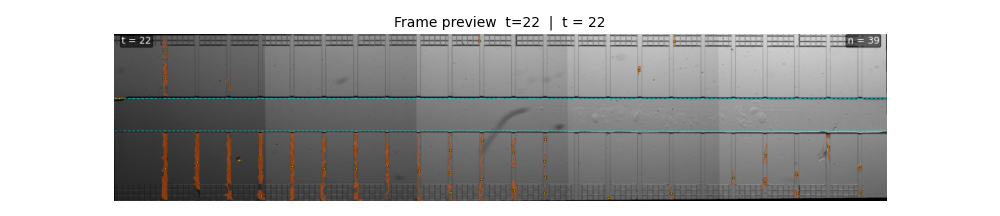

In [80]:
def _time_label(t, show_real_time, times_lookup, t0_dt):
    """Build the time annotation string for one frame."""
    if show_real_time and t in times_lookup and t0_dt is not None:
        elapsed_s = (times_lookup[t] - t0_dt).total_seconds()
        if elapsed_s < 60:
            return f"{elapsed_s:.0f} s"
        elif elapsed_s < 3600:
            return f"{elapsed_s / 60:.1f} min"
        else:
            return f"{elapsed_s / 3600:.2f} h"
    return f"t = {t}"


def render_detection_frame(
    img_bf_raw,
    binary_mask,
    band_info,
    time_label,
    resize_width=1024,
    dpi=100,
    overlay_color=(1.0, 0.35, 0.0),
    overlay_alpha=0.45,
    centroid_color="yellow",
    centroid_size=6,
):
    """
    Render one video frame as a uint8 RGB numpy array.

    Parameters
    ----------
    img_bf_raw    : (H, W) array  – raw brightfield (any dtype/range)
    binary_mask   : (H, W) bool   – detected objects (same shape as img_bf_raw)
    band_info     : dict          – output of detect_channel_from_mask
    time_label    : str           – annotation text (top-left corner)
    resize_width  : int           – output frame width in pixels
    dpi           : int
    overlay_color : (r, g, b) ∈ [0,1]³
    overlay_alpha : float         – opacity of the tint
    centroid_color: str or tuple
    centroid_size : int           – scatter marker size (points)

    Returns
    -------
    frame : np.ndarray uint8  (H', W', 3)
    """
    H, W = img_bf_raw.shape

    # ── Normalise BF & build RGB canvas ──────────────────────────────────────
    img_n = img_bf_raw.astype(np.float32)
    img_n = (img_n - img_n.min()) / (img_n.max() - img_n.min() + 1e-8)
    canvas = np.stack([img_n, img_n, img_n], axis=-1)

    # ── Tint detected regions ─────────────────────────────────────────────────
    if binary_mask.any():
        r, g, b = overlay_color
        a = overlay_alpha
        canvas[binary_mask, 0] = canvas[binary_mask, 0] * (1 - a) + r * a
        canvas[binary_mask, 1] = canvas[binary_mask, 1] * (1 - a) + g * a
        canvas[binary_mask, 2] = canvas[binary_mask, 2] * (1 - a) + b * a

    # ── Centre-of-mass via regionprops ────────────────────────────────────────
    labeled  = sk_label(binary_mask)
    regions  = sk_regionprops(labeled)
    cents_rc = np.array([reg.centroid for reg in regions]) if regions else np.empty((0, 2))

    # ── Matplotlib figure → PNG → numpy ──────────────────────────────────────
    aspect  = H / W
    fig_w   = resize_width / dpi
    fig, ax = plt.subplots(figsize=(fig_w, fig_w * aspect), dpi=dpi)
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

    ax.imshow(np.clip(canvas, 0, 1))

    # Band boundaries
    ax.axhline(band_info["band_top"],    color="cyan", lw=0.8, ls="--", alpha=0.6)
    ax.axhline(band_info["band_bottom"], color="cyan", lw=0.8, ls="--", alpha=0.6)

    # Centroids
    if len(cents_rc):
        ax.scatter(
            cents_rc[:, 1], cents_rc[:, 0],
            c=centroid_color, s=0.1*centroid_size ** 2,
            alpha=0.9, linewidths=0.5, edgecolors="black", zorder=5,
        )

    # Annotations
    _kw = dict(fontsize=9, color="white",
               bbox=dict(boxstyle="round,pad=0.15", fc="black", alpha=0.55))
    ax.text(0.01, 0.98, time_label,        transform=ax.transAxes, va="top", ha="left",  **_kw)
    ax.text(0.99, 0.98, f"n = {len(regions)}", transform=ax.transAxes, va="top", ha="right", **_kw)

    ax.axis("off")

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight", pad_inches=0)
    buf.seek(0)
    frame_arr = np.array(Image.open(buf).convert("RGB"))
    plt.close(fig)
    return frame_arr


# ── Preview a single frame ────────────────────────────────────────────────────
PREVIEW_T = VIDEO_TIMEPOINTS[len(VIDEO_TIMEPOINTS) // 4]   # ~25 % into the video

img_prev, _ = load_frame(PREVIEW_T, CHANNEL_BF)
img_det, _  = load_frame(PREVIEW_T, CHANNEL_OBJECT_DETECT)
mask_prev   = OBJECT_DETECT_FN(img_det, px_um)

if mask_prev.shape != img_prev.shape:
    mask_prev = sk_resize(mask_prev.astype(np.float32), img_prev.shape,
                          order=0, preserve_range=True, anti_aliasing=False).astype(bool)

label_prev = _time_label(PREVIEW_T, SHOW_REAL_TIME, times_lookup, t0_dt)
frame_prev = render_detection_frame(
    img_prev, mask_prev, band_info, label_prev,
    resize_width=VIDEO_RESIZE_WIDTH, dpi=VIDEO_DPI,
    overlay_color=OVERLAY_COLOR, overlay_alpha=OVERLAY_ALPHA,
    centroid_color=CENTROID_COLOR, centroid_size=CENTROID_SIZE,
)

# Show the preview (switch to inline for display)
import matplotlib
%matplotlib widget
# matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as _plt_show
fig_p, ax_p = _plt_show.subplots(figsize=(10, frame_prev.shape[0] / frame_prev.shape[1] * 10))
ax_p.imshow(frame_prev); ax_p.axis("off")
ax_p.set_title(f"Frame preview  t={PREVIEW_T}  |  {label_prev}", fontsize=10)
_plt_show.tight_layout(); _plt_show.show()
matplotlib.use("Agg")   # switch back for video rendering


## 7 · Build & Export Video

Runs the detector on every frame in `VIDEO_TIMEPOINTS`, renders each one with
`render_detection_frame`, and exports a single `.mp4` via moviepy.


In [81]:
VIDEO_OUTPUT_PATH = Path(VIDEO_OUTPUT_PATH)
VIDEO_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

matplotlib.use("Agg")   # ensure non-interactive backend for all frame renders

print(f"Rendering {len(VIDEO_TIMEPOINTS)} frames …")
clips = []

for i, t in enumerate(VIDEO_TIMEPOINTS):
    # ── Load frames ───────────────────────────────────────────────────────────
    img_bf_t, _  = load_frame(t, CHANNEL_BF)
    img_det_t, _ = load_frame(t, CHANNEL_OBJECT_DETECT)

    # ── Detect ────────────────────────────────────────────────────────────────
    binary = OBJECT_DETECT_FN(img_det_t, px_um)
    if binary.shape != img_bf_t.shape:
        binary = sk_resize(binary.astype(np.float32), img_bf_t.shape,
                           order=0, preserve_range=True, anti_aliasing=False).astype(bool)

    # ── Time label ────────────────────────────────────────────────────────────
    label = _time_label(t, SHOW_REAL_TIME, times_lookup, t0_dt)

    # ── Render ────────────────────────────────────────────────────────────────
    frame = render_detection_frame(
        img_bf_t, binary, band_info, label,
        resize_width=VIDEO_RESIZE_WIDTH, dpi=VIDEO_DPI,
        overlay_color=OVERLAY_COLOR, overlay_alpha=OVERLAY_ALPHA,
        centroid_color=CENTROID_COLOR, centroid_size=CENTROID_SIZE,
    )

    n_obj = sk_label(binary).max()
    clips.append(ImageClip(frame, duration=1.0 / VIDEO_FPS))

    if (i + 1) % 10 == 0 or i == 0:
        print(f"  [{i+1:4d}/{len(VIDEO_TIMEPOINTS)}]  t={t}  label={label!r}  n={n_obj}")

# ── Export ────────────────────────────────────────────────────────────────────
print(f"\nExporting → {VIDEO_OUTPUT_PATH} …")
final = concatenate_videoclips(clips, method="compose")
final.write_videofile(
    str(VIDEO_OUTPUT_PATH),
    fps=VIDEO_FPS,
    codec="libx264",
    audio=False,
    ffmpeg_params=[
        "-pix_fmt", "yuv420p",
        "-movflags", "+faststart",
        "-profile:v", "baseline",
        "-vf", "scale=trunc(iw/2)*2:trunc(ih/2)*2",
    ],
    logger=None,
)
print(f"\n✅  Video saved → {VIDEO_OUTPUT_PATH}")
print(f"   {len(clips)} frames  |  {VIDEO_FPS} fps  |  "
      f"~{len(clips)/VIDEO_FPS:.1f} s  |  {frame.shape[1]}×{frame.shape[0]} px")


Rendering 91 frames …
  [   1/91]  t=0  label='t = 0'  n=42
  [  10/91]  t=9  label='t = 9'  n=40
  [  20/91]  t=19  label='t = 19'  n=38
  [  30/91]  t=29  label='t = 29'  n=38
  [  40/91]  t=39  label='t = 39'  n=42
  [  50/91]  t=49  label='t = 49'  n=38
  [  60/91]  t=59  label='t = 59'  n=38
  [  70/91]  t=69  label='t = 69'  n=35
  [  80/91]  t=79  label='t = 79'  n=40
  [  90/91]  t=89  label='t = 89'  n=42

Exporting → /Users/bisot/Documents/PostDoc2/test_data/ICP/ICP15-02/detection_overlay_3.mp4 …

✅  Video saved → /Users/bisot/Documents/PostDoc2/test_data/ICP/ICP15-02/detection_overlay_3.mp4
   91 frames  |  5 fps  |  ~18.2 s  |  1024×222 px
